In [1]:
import os
import re
import time
import string
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to C:\Users\Luka
[nltk_data]     Saric\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\Luka
[nltk_data]     Saric\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to C:\Users\Luka
[nltk_data]     Saric\AppData\Roaming\nltk_data...


True

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

DATA_DIR = "data"

In [4]:
def load_imdb_data(data_dir):
    records = []
    for split in ["train", "test"]:
        for label in ["pos", "neg"]:
            folder = os.path.join(data_dir, split, label)
            for fname in os.listdir(folder):
                if fname.endswith(".txt"):
                    with open(os.path.join(folder, fname), encoding="utf-8") as f:
                        text = f.read()
                    records.append({
                        "review": text,
                        "sentiment": 1 if label == "pos" else 0,
                        "split_origin": split
                    })
    return pd.DataFrame(records)

In [6]:
df = load_imdb_data(f"../{DATA_DIR}")
print(f"Total reviews loaded: {len(df)}")
df.sample(5, random_state=SEED)

Total reviews loaded: 50000


,review,sentiment,split_origin
33553,"When I first saw the ad for this, I was like '...",1,test
9427,"""A Girl's Folly"" is a sort of half-comedy, hal...",1,train
199,I started watching the show from the first sea...,1,train
12447,This is a more interesting than usual porn mov...,1,train
39489,I suppose for 1961 this film was supposed to b...,0,test


Dataset shape: (50000, 3)

Missing values:
 review          0
sentiment       0
split_origin    0
dtype: int64

Duplicate reviews: 418


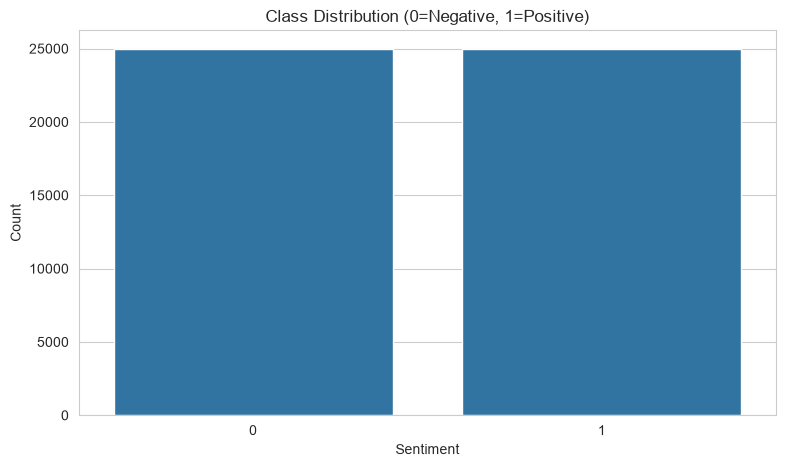

In [7]:
# Exploratory Data Analysis (EDA)
print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate reviews:", df.duplicated(subset="review").sum())

# Class balance
plt.figure()
sns.countplot(x="sentiment", data=df)
plt.title("Class Distribution (0=Negative, 1=Positive)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [8]:
class_balance = df["sentiment"].value_counts(normalize=True)
print("Class balance (proportion):\n", class_balance)
IS_BALANCED = np.isclose(class_balance[0], class_balance[1], atol=0.02)
print(f"Dataset is {'balanced' if IS_BALANCED else 'imbalanced'} -> "
      f"{'Accuracy is a valid metric' if IS_BALANCED else 'prefer F1/ROC-AUC over accuracy'}")

Class balance (proportion):
 sentiment
1    0.5
0    0.5
Name: proportion, dtype: float64
Dataset is balanced -> Accuracy is a valid metric


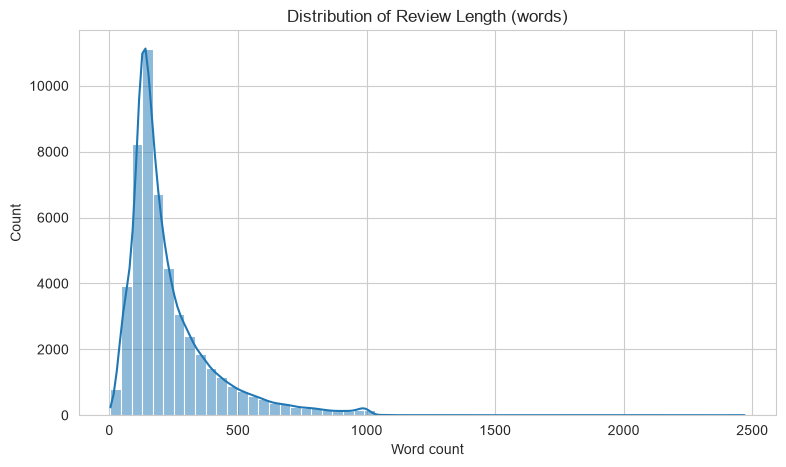

In [9]:
# Review length analysis
df["review_length_words"] = df["review"].apply(lambda x: len(x.split()))
df["review_length_chars"] = df["review"].apply(len)

plt.figure()
sns.histplot(df["review_length_words"], bins=60, kde=True)
plt.title("Distribution of Review Length (words)")
plt.xlabel("Word count")
plt.show()

In [10]:
print(df["review_length_words"].describe())

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length_words, dtype: float64


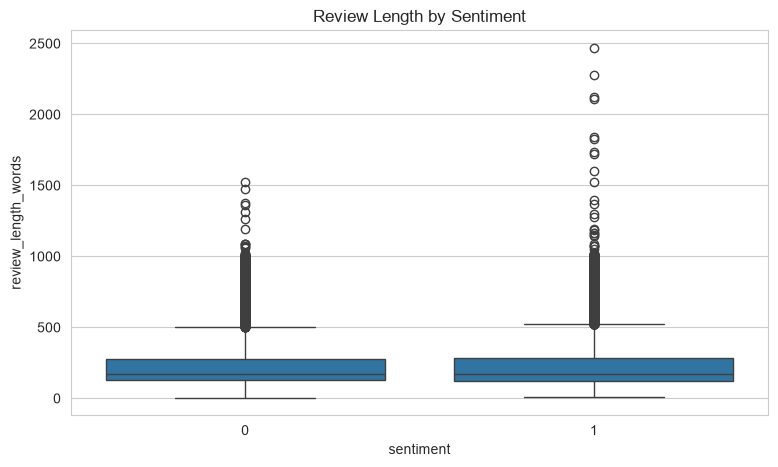

In [11]:
plt.figure()
sns.boxplot(x="sentiment", y="review_length_words", data=df)
plt.title("Review Length by Sentiment")
plt.show()

In [12]:
html_tag_count = df["review"].str.contains(r"<br\s*/?>").sum()
print(f"Reviews containing HTML break tags: {html_tag_count} ({html_tag_count/len(df)*100:.1f}%)")

Reviews containing HTML break tags: 29200 (58.4%)


In [13]:
# Most common words per class (raw, before cleaning)
def get_top_words(texts, n=20):
    words = " ".join(texts).lower().split()
    words = [w.strip(string.punctuation) for w in words]
    return Counter(words).most_common(n)

print("Top raw tokens (positive):", get_top_words(df[df.sentiment==1]["review"].sample(2000, random_state=SEED)))
print("Top raw tokens (negative):", get_top_words(df[df.sentiment==0]["review"].sample(2000, random_state=SEED)))

Top raw tokens (positive): [('the', 27252), ('and', 13943), ('a', 13125), ('of', 12204), ('to', 10531), ('is', 8868), ('in', 7979), ('it', 6286), ('i', 5979), ('this', 5515), ('that', 5406), ('br', 4362), ('as', 4051), ('with', 3763), ('was', 3591), ('for', 3483), ('but', 3245), ('film', 3183), ('movie', 2814), ('his', 2716)]
Top raw tokens (negative): [('the', 25414), ('a', 12548), ('and', 11303), ('to', 10854), ('of', 10685), ('is', 7859), ('in', 6827), ('i', 6493), ('this', 6270), ('it', 6181), ('that', 5443), ('br', 4779), ('was', 4105), ('movie', 3711), ('for', 3350), ('but', 3310), ('as', 3200), ('with', 3104), ('on', 2721), ('film', 2715)]


In [14]:
# Preprocessing
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = re.sub(r"<.*?>", " ", text)                  # remove HTML tags
    text = re.sub(r"http\S+|www\S+", " ", text)          # remove URLs
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)                # keep only letters
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

In [15]:
t0 = time.time()
df["clean_review"] = df["review"].apply(clean_text)
print(f"Text cleaning took {time.time() - t0:.2f}s")

df["clean_length"] = df["clean_review"].apply(lambda x: len(x.split()))

Text cleaning took 26.61s


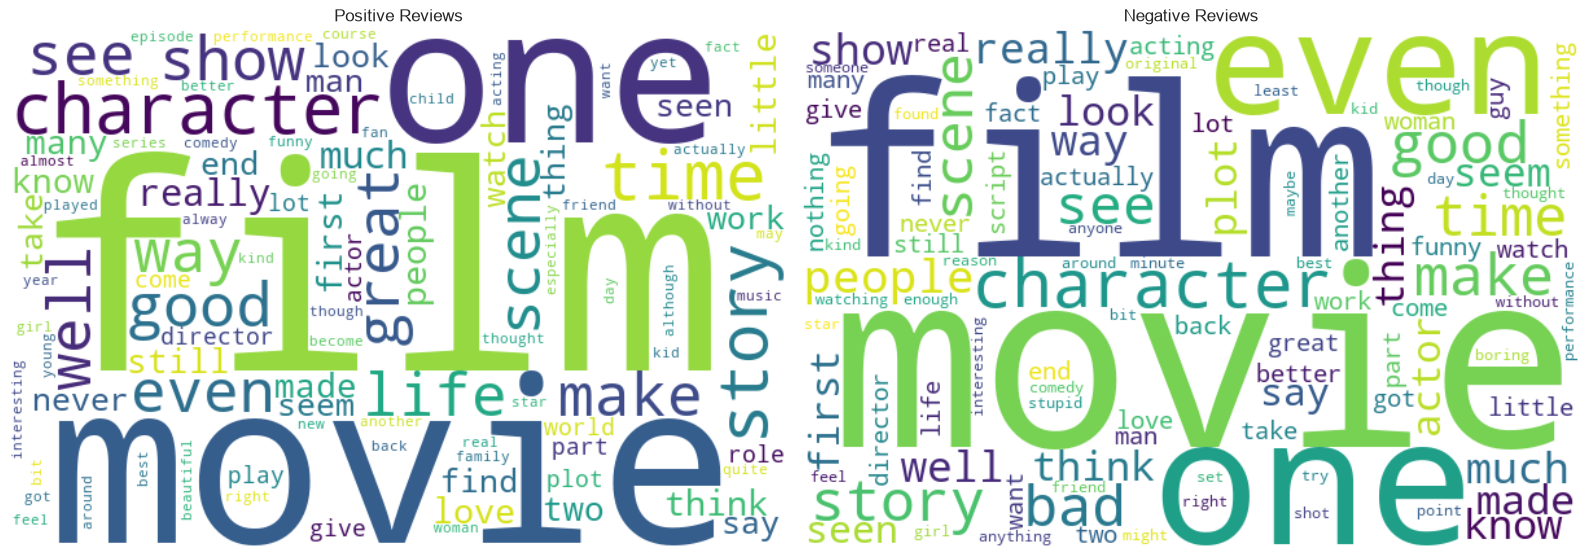

In [16]:
# Word clouds per class (visual EDA after cleaning)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, label, title in zip(axes, [1, 0], ["Positive Reviews", "Negative Reviews"]):
    text_blob = " ".join(df[df.sentiment == label]["clean_review"].sample(3000, random_state=SEED))
    wc = WordCloud(width=600, height=400, background_color="white", max_words=100).generate(text_blob)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [18]:
# Train/Test Split
X_train = df[df["split_origin"] == "train"]["clean_review"]
y_train = df[df["split_origin"] == "train"]["sentiment"]

X_test = df[df["split_origin"] == "test"]["clean_review"]
y_test = df[df["split_origin"] == "test"]["sentiment"]

In [20]:
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 25000 | Test size: 25000


In [21]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=5,
    max_df=0.9
)

In [25]:
t0 = time.time()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
vectorize_time = time.time() - t0
print(f"TF-IDF vectorization took {vectorize_time:.2f}s")
print(f"Feature matrix shape: {X_train_tfidf.shape}")

TF-IDF vectorization took 12.70s
Feature matrix shape: (25000, 50000)


In [27]:
# Model Training (Logistic Regression) + Timing
log_reg = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)

t0 = time.time()
log_reg.fit(X_train_tfidf, y_train)
lr_train_time = time.time() - t0
print(f"Logistic Regression training time: {lr_train_time:.2f}s")

Logistic Regression training time: 0.23s


In [28]:
# Model Training (Linear SVM) + Timing
svm_clf = LinearSVC(C=1.0, random_state=SEED)

t0 = time.time()
svm_clf.fit(X_train_tfidf, y_train)
svm_train_time = time.time() - t0
print(f"Linear SVM training time: {svm_train_time:.2f}s")

Linear SVM training time: 0.31s


In [29]:
# Calibrate SVM to get probability estimates for ROC-AUC
svm_calibrated = CalibratedClassifierCV(svm_clf, cv=3)
t0 = time.time()
svm_calibrated.fit(X_train_tfidf, y_train)
svm_calib_time = time.time() - t0
print(f"SVM calibration time: {svm_calib_time:.2f}s")

SVM calibration time: 0.65s


In [30]:
# Evaluation Function
def evaluate_model(model, X_test, y_test, model_name, has_proba=True):
    y_pred = model.predict(X_test)
    if has_proba:
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"\n===== {model_name} Evaluation =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(ax=axes[0], cmap="Blues")
    axes[0].set_title(f"{model_name} — Confusion Matrix")

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"{model_name} — ROC Curve")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    return {"model": model_name, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "roc_auc": roc_auc}


===== TF-IDF + Logistic Regression Evaluation =====
Accuracy : 0.8921
Precision: 0.8893
Recall   : 0.8957
F1-score : 0.8925
ROC-AUC  : 0.9583

Classification Report:
               precision    recall  f1-score   support

    Negative       0.89      0.89      0.89     12500
    Positive       0.89      0.90      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



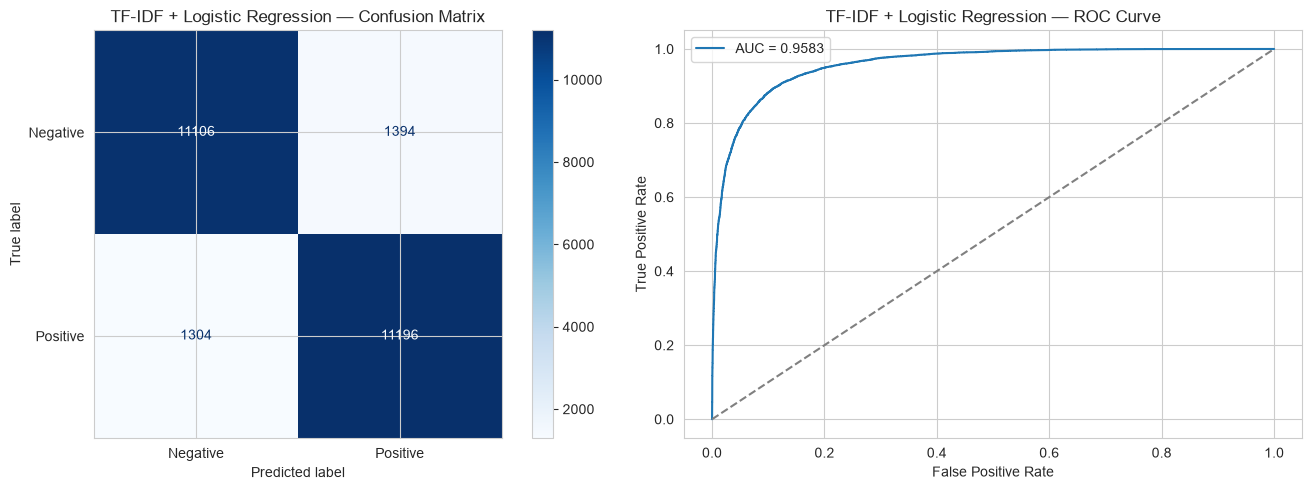


===== TF-IDF + Linear SVM Evaluation =====
Accuracy : 0.8923
Precision: 0.8843
Recall   : 0.9026
F1-score : 0.8934
ROC-AUC  : 0.9581

Classification Report:
               precision    recall  f1-score   support

    Negative       0.90      0.88      0.89     12500
    Positive       0.88      0.90      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



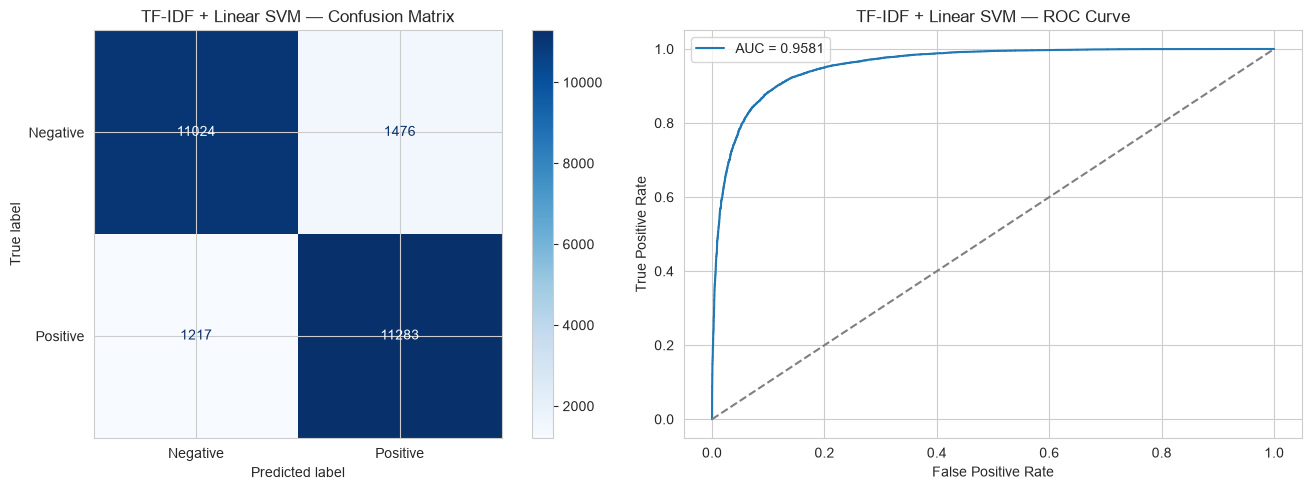

In [31]:
# Run Evaluation
results = []
results.append(evaluate_model(log_reg, X_test_tfidf, y_test, "TF-IDF + Logistic Regression", has_proba=True))
results.append(evaluate_model(svm_calibrated, X_test_tfidf, y_test, "TF-IDF + Linear SVM", has_proba=True))

In [32]:
# Top Predictive Features (interpretability)
feature_names = np.array(tfidf.get_feature_names_out())
coefs = log_reg.coef_[0]
top_pos_idx = np.argsort(coefs)[-20:]
top_neg_idx = np.argsort(coefs)[:20]

print("Top 20 words pushing toward POSITIVE sentiment:")
print(list(feature_names[top_pos_idx]))
print("\nTop 20 words pushing toward NEGATIVE sentiment:")
print(list(feature_names[top_neg_idx]))


Top 20 words pushing toward POSITIVE sentiment:
['also', 'fantastic', 'beautiful', 'highly', 'enjoyed', 'superb', 'brilliant', 'today', 'one best', 'love', 'loved', 'fun', 'well', 'favorite', 'amazing', 'best', 'wonderful', 'perfect', 'excellent', 'great']

Top 20 words pushing toward NEGATIVE sentiment:
['worst', 'bad', 'awful', 'boring', 'waste', 'poor', 'nothing', 'terrible', 'worse', 'dull', 'horrible', 'unfortunately', 'poorly', 'stupid', 'supposed', 'annoying', 'script', 'even', 'instead', 'ridiculous']


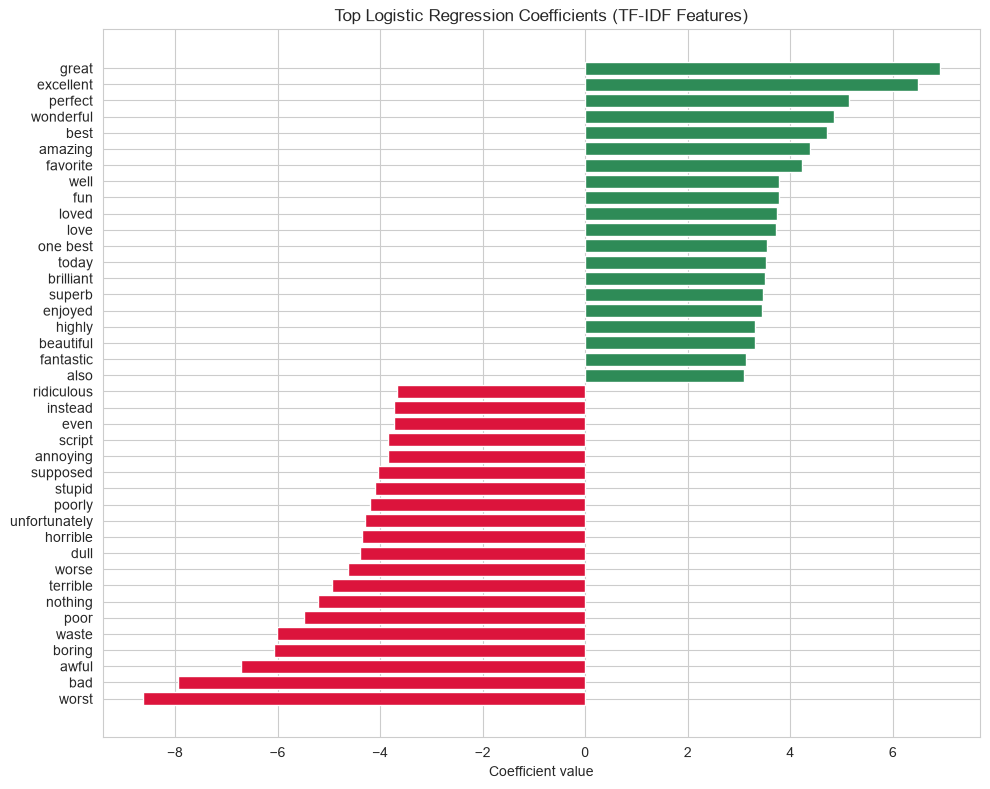

In [33]:
plt.figure(figsize=(10, 8))
all_idx = np.concatenate([top_neg_idx, top_pos_idx])
plt.barh(feature_names[all_idx], coefs[all_idx],
         color=["crimson" if c < 0 else "seagreen" for c in coefs[all_idx]])
plt.title("Top Logistic Regression Coefficients (TF-IDF Features)")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()

In [34]:
# Final Summary — Timing & Metrics
results_df = pd.DataFrame(results)
print("\n================= FINAL RESULTS SUMMARY =================")
print(results_df.to_string(index=False))

print("\n================= TIMING SUMMARY =================")
print(f"TF-IDF vectorization time : {vectorize_time:.2f}s")
print(f"Logistic Regression train : {lr_train_time:.2f}s")
print(f"Linear SVM train          : {svm_train_time:.2f}s")
print(f"SVM calibration time      : {svm_calib_time:.2f}s")
print(f"TOTAL pipeline time (LR)  : {vectorize_time + lr_train_time:.2f}s")
print(f"TOTAL pipeline time (SVM) : {vectorize_time + svm_train_time + svm_calib_time:.2f}s")



================= FINAL RESULTS SUMMARY =================
                       model  accuracy  precision  recall       f1  roc_auc
TF-IDF + Logistic Regression   0.89208   0.889277 0.89568 0.892467 0.958334
         TF-IDF + Linear SVM   0.89228   0.884317 0.90264 0.893385 0.958137

================= TIMING SUMMARY =================
TF-IDF vectorization time : 12.70s
Logistic Regression train : 0.23s
Linear SVM train          : 0.31s
SVM calibration time      : 0.65s
TOTAL pipeline time (LR)  : 12.92s
TOTAL pipeline time (SVM) : 13.65s


In [35]:
# Save results for cross-notebook comparison
results_df.to_csv("tfidf_results.csv", index=False)